In [9]:
#!/usr/bin/env python
# coding: utf-8

# # 🎓 Análise de Bolsas de Estudo Universitárias ao Redor do Mundo
#
# ## Objetivo do Estudo
#
# Este notebook aplica um fluxo completo de análise de dados — limpeza, exploração,
# visualização, testes estatísticos e conclusões — sobre o dataset **"Universities
# Scholarships All Around the World"** (Kaggle / scholarshipportal.com).
#
# ## Sobre o conjunto de dados
#
# - 📦 **Registros:** 879 oportunidades de bolsa de estudo
# - 🌍 **Variáveis:** título, níveis de ensino contemplados (`degrees`), valor/tipo de
#   financiamento (`funds`), prazo de inscrição (`date`) e país/região (`location`)
# - 🎯 **Meta:** entender como o financiamento, o nível de ensino e a geografia se
#   relacionam nas oportunidades de bolsa disponíveis
#
# ## Perguntas de investigação
#
# 1. 🌍 Como as bolsas estão distribuídas geograficamente — quais países concentram mais oportunidades?
# 2. 🎓 O nível de ensino contemplado (Bachelor, Master, PhD, Course) está associado ao tipo de financiamento oferecido?
# 3. 💰 Qual o tipo de financiamento predominante, e como o valor numérico varia entre moedas e países?
# 4. 📅 Existe sazonalidade nos prazos de inscrição ao longo do ano?
#

# ## 1. Preparação dos Dados
#
# ### a) Carregando e inspecionando o dataset

# In[ ]:


import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False


# ### Envio do arquivo de dados
#
# Rode a célula abaixo e clique em **"Escolher arquivos"** para selecionar o CSV
# (`Universities_Schoolarships_All_Around_the_World.csv`) no seu computador.

# In[ ]:


from google.colab import files

print("Clique no botão abaixo para escolher o seu arquivo (archive.zip ou CSV):")
uploaded = files.upload()

Clique no botão abaixo para escolher o seu arquivo (archive.zip ou CSV):


Saving Universities_Schoolarships_All_Around_the_World.csv to Universities_Schoolarships_All_Around_the_World (4).csv


In [10]:

# Pega automaticamente o nome do arquivo que você acabou de enviar
nome_arquivo = list(uploaded.keys())[0]

print(f"📂 Carregando dataset de bolsas de estudo... ({nome_arquivo})")
df = pd.read_csv(nome_arquivo, index_col=0)

print(f"\n📊 Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"📋 Colunas: {list(df.columns)}")
print("\n🔍 Primeiras 5 linhas:")
df.head()



📂 Carregando dataset de bolsas de estudo... (Universities_Schoolarships_All_Around_the_World (4).csv)

📊 Dimensões: 879 linhas x 5 colunas
📋 Colunas: ['title', 'degrees', 'funds', 'date', 'location']

🔍 Primeiras 5 linhas:


,title,degrees,funds,date,location
0,Schaefer Halleen’s Social Equity Scholarship,"Master, Bachelor, Phd",$1000,30 June 2022,united-states
1,President’s Scholarship for Ukraine,"Master, Bachelor, Phd, Course",$2500,31 July 2022,united-states
2,International Students Diversity Contest 2022-2023,"Master, Bachelor, Phd, Course","Up to $2,000",22 December 2022,united-states
3,Master in Business Administration 80% OFF your Tuition fee,Master,80% Tuition Fees,15 September 2022,united-states
4,Improve Men’s Health Scholarship,"Master, Bachelor, Phd",$2000,31 May 2022,united-states


In [11]:

print("🧼 Verificando dados ausentes:")
ausentes = df.isnull().sum()
pct_ausentes = (ausentes / len(df) * 100).round(1)
resumo_ausentes = pd.DataFrame({'ausentes': ausentes, 'pct': pct_ausentes})
print(resumo_ausentes[resumo_ausentes['ausentes'] > 0])

print("\n🔎 Valores únicos em 'degrees':")
print(df['degrees'].value_counts())
print("\n🔎 Localizações (location):")
print(df['location'].value_counts())

🧼 Verificando dados ausentes:
         ausentes   pct
degrees        49   5.6
funds          85   9.7
date          291  33.1

🔎 Valores únicos em 'degrees':
degrees
Phd                              156
Bachelor                         134
Master                           132
Master, Bachelor, Course          82
Course                            48
Bachelor, Master                  45
Master, Bachelor                  44
Master, Bachelor, Phd, Course     41
Bachelor, Master, Phd             31
Master, Bachelor, Phd             24
Master, Phd                       20
Not Funded                        19
Master, Course                    16
Bachelor, Master, Phd, Course     12
Course, Master                     8
Fully Funded                       8
Phd, Master, Bachelor              3
Bachelor, Course                   3
Phd, Master                        2
Phd, Master, Bachelor, Course      1
Bachelor, Phd, Master              1
Name: count, dtype: int64

🔎 Localizações (location):
loc

In [12]:


# ### b) Limpeza dos dados
#
# Antes de seguir para a análise, três decisões de limpeza precisam ser tomadas:
#
# 1. **Anomalia em `degrees`**: 27 registros trazem `"Not Funded"` ou `"Fully Funded"` na
#    coluna de nível de ensino — claramente um vazamento de informação de financiamento
#    (não um nível de ensino real, já que `funds` está vazio nesses casos). Vamos separar
#    esse dado em uma coluna própria (`status_bolsa_avulso`) e tratar `degrees` como
#    ausente nesses registros.
# 2. **`degrees` é multi-rótulo** (ex.: `"Master, Bachelor, Course"`) — vamos criar colunas
#    binárias `nivel_bachelor`, `nivel_master`, `nivel_phd`, `nivel_course`.
# 3. **`funds` é texto livre e heterogêneo** (`"$1000"`, `"£10,000"`, `"25% Tuition Rate"`,
#    `"Full cost of tuition fees"`, `"Up to $2,000"`...) — vamos classificá-lo em uma
#    **categoria de financiamento** e, quando possível, extrair um **valor numérico**.
# 4. **`date`** mistura datas reais (`"30 June 2022"`), prazo rolante (`"Always Active"`)
#    e indefinido (`"Varies"`, `"Invalid date"`) — vamos separar isso em um `prazo_status`
#    e, quando aplicável, um `data_prazo` real.
#

# In[ ]:


# --- 1. Anomalia em 'degrees' (vazamento de status de financiamento) ---
status_leak = df['degrees'].isin(['Not Funded', 'Fully Funded'])
df['status_bolsa_avulso'] = np.where(status_leak, df['degrees'], np.nan)
df.loc[status_leak, 'degrees'] = np.nan
print(f"✅ {status_leak.sum()} registros com vazamento de status corrigidos em 'degrees'")

# --- 2. Níveis de ensino em colunas binárias (multi-rótulo) ---
for nivel in ['Bachelor', 'Master', 'Phd', 'Course']:
    df[f'nivel_{nivel.lower()}'] = df['degrees'].fillna('').str.contains(nivel, case=False)
print("✅ Colunas binárias de nível de ensino criadas: nivel_bachelor, nivel_master, nivel_phd, nivel_course")



✅ 27 registros com vazamento de status corrigidos em 'degrees'
✅ Colunas binárias de nível de ensino criadas: nivel_bachelor, nivel_master, nivel_phd, nivel_course


In [13]:

# --- 3. Categorização do financiamento (funds) ---
def classify_funds(x):
    """Classifica o texto livre de 'funds' em uma categoria de financiamento."""
    if pd.isna(x):
        return 'Não informado'
    s = str(x).lower()
    if any(k in s for k in ['full', 'fully', '100%', 'free', 'entire']):
        return 'Cobertura Total'
    if '%' in s:
        return 'Percentual'
    if '$' in s or 'usd' in s:
        return 'Valor Fixo (USD)'
    if '£' in s or 'gbp' in s:
        return 'Valor Fixo (GBP)'
    if '€' in s or 'eur' in s:
        return 'Valor Fixo (EUR)'
    return 'Outro/Não especificado'

df['categoria_financiamento'] = df['funds'].apply(classify_funds)

def extract_numeric(x):
    """Extrai o valor numérico de um texto de financiamento.
    Trata separador de milhar tanto em formato EUA (vírgula) quanto europeu (ponto),
    e faz a média quando há uma faixa de valores (ex.: '$100 to $3000')."""
    if pd.isna(x):
        return np.nan
    nums_raw = re.findall(r'[\d.,]+', str(x))
    vals = []
    for n in nums_raw:
        n = n.strip('.,')
        if not n:
            continue
        # "13.000" (padrão europeu de milhar) vira 13000; senão, vírgula é milhar
        n2 = n.replace('.', '') if re.match(r'^\d{1,3}\.\d{3}$', n) else n.replace(',', '')
        try:
            vals.append(float(n2))
        except ValueError:
            continue
    return np.mean(vals) if vals else np.nan

moeda_cats = ['Valor Fixo (USD)', 'Valor Fixo (GBP)', 'Valor Fixo (EUR)']
df['valor_numerico'] = np.where(
    df['categoria_financiamento'].isin(moeda_cats),
    df['funds'].apply(extract_numeric),
    np.nan
)
print("✅ Financiamento classificado em categorias e valores numéricos extraídos")
print(df['categoria_financiamento'].value_counts())



✅ Financiamento classificado em categorias e valores numéricos extraídos
categoria_financiamento
Valor Fixo (USD)          264
Cobertura Total           211
Valor Fixo (GBP)          126
Outro/Não especificado    118
Não informado              85
Percentual                 67
Valor Fixo (EUR)            8
Name: count, dtype: int64


In [14]:
# --- 4. Tratamento de prazos (date) ---
df['prazo_status'] = np.select(
    [df['date'] == 'Always Active',
     df['date'].isin(['Varies', 'Invalid date']),
     df['date'].notna()],
    ['Fluxo contínuo', 'Indefinido', 'Data definida'],
    default='Não informado'
)
df['data_prazo'] = pd.to_datetime(df['date'], format='%d %B %Y', errors='coerce')
df['mes_prazo'] = df['data_prazo'].dt.month_name()

print("✅ Prazos classificados:")
print(df['prazo_status'].value_counts())

print(f"\n📐 Dataset pronto para análise! Dimensões finais: {df.shape}")

✅ Prazos classificados:
prazo_status
Data definida     333
Não informado     291
Fluxo contínuo    253
Indefinido          2
Name: count, dtype: int64

📐 Dataset pronto para análise! Dimensões finais: (879, 15)


In [15]:

# ### c) Estatísticas gerais
#
# Antes de responder às perguntas de investigação, um panorama geral do dataset já
# limpo e enriquecido.

# In[ ]:


total_bolsas = len(df)
pct_cobertura_total = (df['categoria_financiamento'] == 'Cobertura Total').mean() * 100
pct_com_valor_definido = df['categoria_financiamento'].isin(moeda_cats).mean() * 100
pct_prazo_indefinido = df['prazo_status'].isin(['Fluxo contínuo', 'Indefinido']).mean() * 100
pais_top = df['location'].value_counts().idxmax()

print("📊 PANORAMA GERAL DO DATASET")
print("=" * 50)
print(f"🎓 Total de bolsas catalogadas: {total_bolsas}")
print(f"💯 Bolsas com cobertura total: {pct_cobertura_total:.1f}%")
print(f"💵 Bolsas com valor numérico definido (USD/GBP/EUR): {pct_com_valor_definido:.1f}%")
print(f"🔄 Bolsas com prazo rolante ou indefinido: {pct_prazo_indefinido:.1f}%")
print(f"🌍 País com mais oportunidades: {pais_top} ({df['location'].value_counts().max()} bolsas)")
print(f"🎯 Bolsas para PhD: {df['nivel_phd'].mean()*100:.1f}% | Master: {df['nivel_master'].mean()*100:.1f}% | Bachelor: {df['nivel_bachelor'].mean()*100:.1f}% | Course: {df['nivel_course'].mean()*100:.1f}%")



📊 PANORAMA GERAL DO DATASET
🎓 Total de bolsas catalogadas: 879
💯 Bolsas com cobertura total: 24.0%
💵 Bolsas com valor numérico definido (USD/GBP/EUR): 45.3%
🔄 Bolsas com prazo rolante ou indefinido: 29.0%
🌍 País com mais oportunidades: united-kingdom (309 bolsas)
🎯 Bolsas para PhD: 33.1% | Master: 52.6% | Bachelor: 47.9% | Course: 24.0%


/tmp/ipykernel_1080/3612914885.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='location', data=df, order=ordem_loc, palette='pastel', ax=ax1)


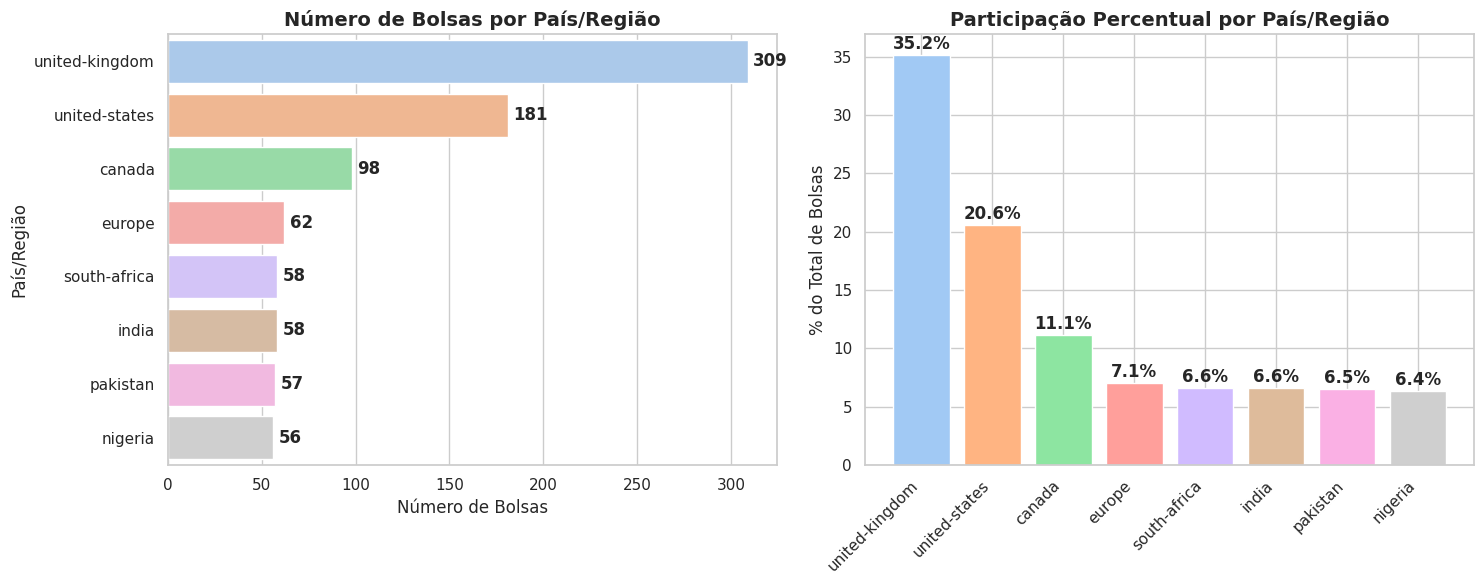

🔎 Insights por País/Região:
✓ united-kingdom: 309 bolsas (35.2% do total)
✓ united-states: 181 bolsas (20.6% do total)
✓ canada: 98 bolsas (11.1% do total)
✓ europe: 62 bolsas (7.1% do total)
✓ south-africa: 58 bolsas (6.6% do total)
✓ india: 58 bolsas (6.6% do total)
✓ pakistan: 57 bolsas (6.5% do total)
✓ nigeria: 56 bolsas (6.4% do total)


In [16]:
# ## 2. Pergunta 1: Como as bolsas estão distribuídas geograficamente?
#
# **Hipótese:** países de sistemas universitários fortemente internacionalizados
# (Reino Unido, Estados Unidos, Canadá) concentram a maior parte das oportunidades
# listadas, refletindo tanto a quantidade de universidades quanto o volume de
# programas voltados a estudantes internacionais.

# In[ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ordem_loc = df['location'].value_counts().index

# Gráfico 1: Contagem de bolsas por país
sns.countplot(y='location', data=df, order=ordem_loc, palette='pastel', ax=ax1)
ax1.set_title('Número de Bolsas por País/Região', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Bolsas')
ax1.set_ylabel('País/Região')
for i, pais in enumerate(ordem_loc):
    total = (df['location'] == pais).sum()
    ax1.text(total + 3, i, f'{total}', va='center', fontweight='bold')

# Gráfico 2: Participação percentual
participacao = (df['location'].value_counts(normalize=True) * 100).reindex(ordem_loc)
ax2.bar(range(len(participacao)), participacao.values, color=sns.color_palette('pastel', len(participacao)))
ax2.set_title('Participação Percentual por País/Região', fontsize=14, fontweight='bold')
ax2.set_ylabel('% do Total de Bolsas')
ax2.set_xticks(range(len(participacao)))
ax2.set_xticklabels(participacao.index, rotation=45, ha='right')
for i, v in enumerate(participacao.values):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("🔎 Insights por País/Região:")
print("=" * 50)
for pais in ordem_loc:
    total = (df['location'] == pais).sum()
    pct = total / len(df) * 100
    print(f"✓ {pais}: {total} bolsas ({pct:.1f}% do total)")


# **Insights**
# - Reino Unido (35,2%) e Estados Unidos (20,6%) concentram, juntos, mais da metade
#   (55,7%) das bolsas catalogadas — muito à frente de Canadá (11,1%), que vem em terceiro.
# - Os quatro países seguintes (Europa continental, África do Sul, Índia e Paquistão/Nigéria)
#   têm participação muito mais equilibrada entre si (6-7% cada), sugerindo que a cauda do
#   dataset é mais pulverizada geograficamente do que a cabeça.
#
# **Conclusões**
# - ✅ A hipótese se confirma parcialmente: Reino Unido e EUA de fato dominam, mas o
#   Canadá tem participação mais modesta do que o esperado frente aos outros dois.
# - ✅ A concentração em poucos países é coerente com o fato de o dataset vir de um
#   portal (scholarshipportal.com) voltado a estudantes internacionais, que tende a
#   indexar prioritariamente universidades anglófonas.

/tmp/ipykernel_1080/3983477454.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nomes_niveis, y=contagens, palette='pastel', ax=ax1)


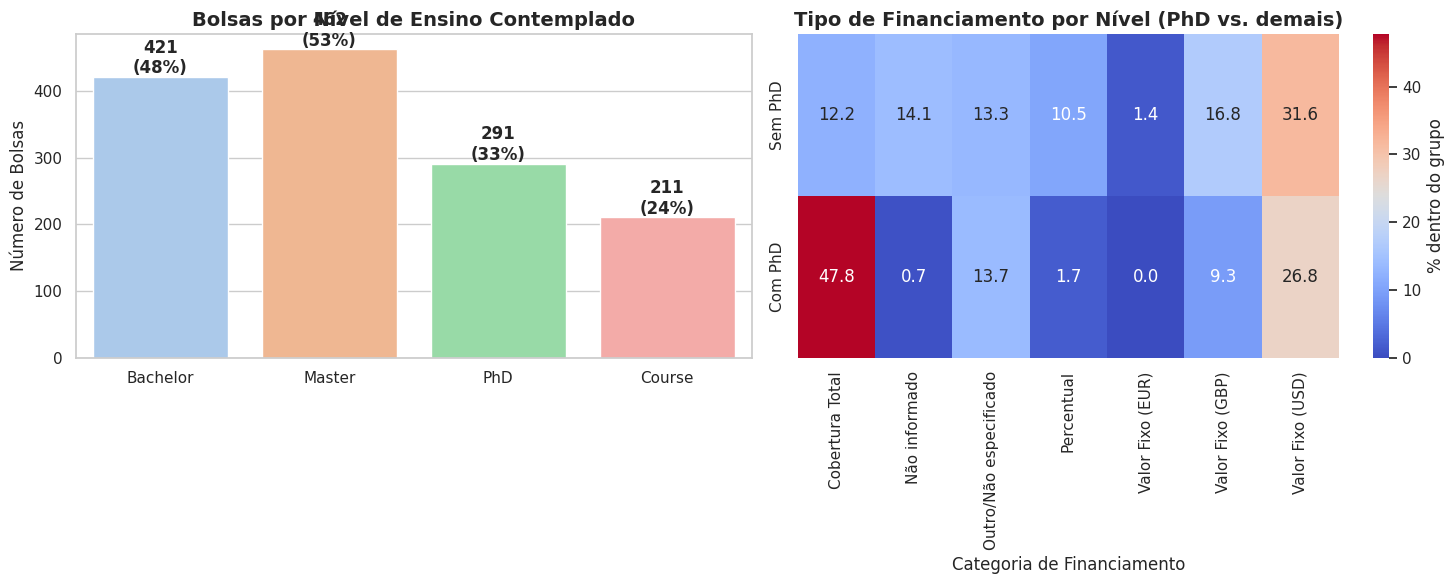

🔎 Insights — Financiamento por nível PhD:
categoria_financiamento  Cobertura Total  Não informado  \
Sem PhD                             12.2           14.1   
Com PhD                             47.8            0.7   

categoria_financiamento  Outro/Não especificado  Percentual  Valor Fixo (EUR)  \
Sem PhD                                    13.3        10.5               1.4   
Com PhD                                    13.7         1.7               0.0   

categoria_financiamento  Valor Fixo (GBP)  Valor Fixo (USD)  
Sem PhD                              16.8              31.6  
Com PhD                               9.3              26.8  
📐 Teste Qui-Quadrado — Nível PhD x Cobertura Total de Financiamento
Estatística qui-quadrado: 132.70
Graus de liberdade: 1
p-valor: 1.05e-30
✅ Associação estatisticamente significativa (p < 0.05): nível PhD e cobertura
   total de financiamento NÃO são independentes.

✓ Bolsas de PhD com cobertura total: 47.8%
✓ Bolsas sem PhD com cobertura total: 

In [17]:

# ## 3. Pergunta 2: O nível de ensino está associado ao tipo de financiamento?
#
# **Hipótese:** bolsas de doutorado (PhD) tendem a oferecer cobertura financeira mais
# completa do que bolsas de graduação (Bachelor), refletindo o investimento em
# pesquisa e o papel do doutorando como força de trabalho acadêmica.

# In[ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Quantidade de bolsas por nível de ensino
niveis = ['nivel_bachelor', 'nivel_master', 'nivel_phd', 'nivel_course']
nomes_niveis = ['Bachelor', 'Master', 'PhD', 'Course']
contagens = [df[n].sum() for n in niveis]
sns.barplot(x=nomes_niveis, y=contagens, palette='pastel', ax=ax1)
ax1.set_title('Bolsas por Nível de Ensino Contemplado', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Bolsas')
for i, v in enumerate(contagens):
    ax1.text(i, v + 5, f'{v}\n({v/len(df)*100:.0f}%)', ha='center', fontweight='bold')

# Gráfico 2: Heatmap PhD (sim/não) x categoria de financiamento (%)
tabela_phd = pd.crosstab(df['nivel_phd'], df['categoria_financiamento'], normalize='index') * 100
tabela_phd.index = ['Sem PhD', 'Com PhD']
sns.heatmap(tabela_phd, annot=True, fmt='.1f', cmap='coolwarm', ax=ax2, cbar_kws={'label': '% dentro do grupo'})
ax2.set_title('Tipo de Financiamento por Nível (PhD vs. demais)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Categoria de Financiamento')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("🔎 Insights — Financiamento por nível PhD:")
print("=" * 50)
print(tabela_phd.round(1))


# In[ ]:


# Teste estatístico: PhD x cobertura total é independente?
df['eh_cobertura_total'] = df['categoria_financiamento'] == 'Cobertura Total'
tabela_teste = pd.crosstab(df['nivel_phd'], df['eh_cobertura_total'])
chi2, p, dof, esperado = stats.chi2_contingency(tabela_teste)

print("📐 Teste Qui-Quadrado — Nível PhD x Cobertura Total de Financiamento")
print("=" * 50)
print(f"Estatística qui-quadrado: {chi2:.2f}")
print(f"Graus de liberdade: {dof}")
print(f"p-valor: {p:.2e}")
if p < 0.05:
    print("✅ Associação estatisticamente significativa (p < 0.05): nível PhD e cobertura")
    print("   total de financiamento NÃO são independentes.")
else:
    print("❌ Não há evidência de associação significativa (p >= 0.05).")

pct_phd_total = df.loc[df['nivel_phd'], 'eh_cobertura_total'].mean() * 100
pct_naophd_total = df.loc[~df['nivel_phd'], 'eh_cobertura_total'].mean() * 100
print(f"\n✓ Bolsas de PhD com cobertura total: {pct_phd_total:.1f}%")
print(f"✓ Bolsas sem PhD com cobertura total: {pct_naophd_total:.1f}%")
print(f"✓ Diferença: {pct_phd_total - pct_naophd_total:.1f} pontos percentuais")


# **Insights**
# - Master (52,6%) é o nível mais contemplado, seguido de Bachelor (47,9%), PhD
#   (33,1%) e Course (24,0%) — a maioria das bolsas atende a mais de um nível ao
#   mesmo tempo.
# - Bolsas de PhD têm cobertura total em 47,8% dos casos, contra apenas 12,2% entre as
#   demais — quase 4x mais chance de financiamento completo.
# - O teste qui-quadrado confirma associação estatisticamente muito significativa
#   (p < 0,001) entre ser bolsa de PhD e oferecer cobertura total.
#
# **Conclusões**
# - ✅ A hipótese se confirma com forte evidência estatística: bolsas de doutorado
#   realmente concentram financiamento mais completo, coerente com o modelo de
#   financiamento acadêmico onde o doutorando recebe bolsa + isenção de mensalidade.
# - ✅ Bolsas de Bachelor e Course dependem proporcionalmente mais de valores fixos
#   ou parciais, o que é relevante para quem planeja o orçamento de graduação.

/tmp/ipykernel_1080/565542779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='categoria_financiamento', data=df, order=ordem_cat, palette='pastel', ax=ax1)
/tmp/ipykernel_1080/565542779.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria_financiamento', y='valor_numerico', data=moeda_df, palette='pastel', ax=ax2)


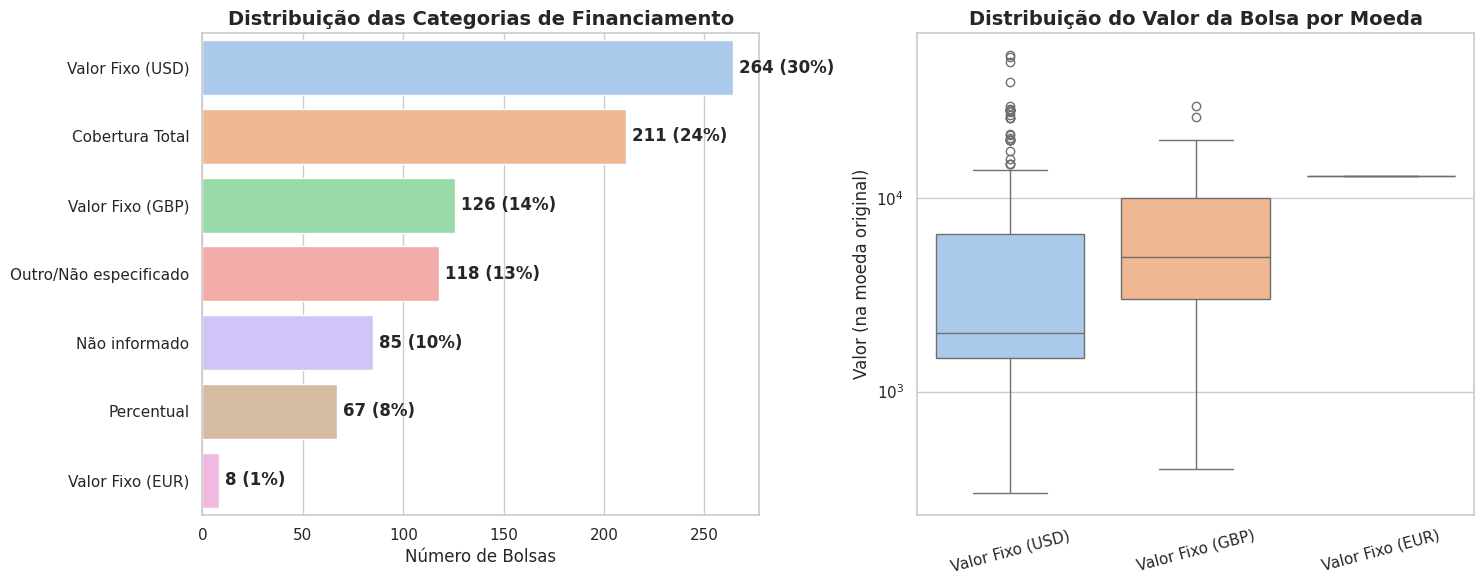

💰 Estatísticas do Valor Numérico por Categoria de Moeda:
                         count     mean      50%      min      max
categoria_financiamento                                           
Valor Fixo (EUR)           8.0  13000.0  13000.0  13000.0  13000.0
Valor Fixo (GBP)         126.0   6658.0   5000.0    400.0  30000.0
Valor Fixo (USD)         264.0   5982.0   2000.0    300.0  55000.0
📐 Teste de Kruskal-Wallis — Valor da bolsa (USD) entre países
Países comparados: ['canada', 'europe', 'india', 'nigeria', 'pakistan', 'south-africa', 'united-kingdom', 'united-states']
Estatística H: 13.32 | p-valor: 0.0647
❌ Não há evidência forte de diferença entre os países para bolsas em USD
   (o valor em dólar tende a ser definido por padrões do próprio programa,
   mais do que pelo país de origem da universidade).


In [18]:
# ## 4. Pergunta 3: Qual o tipo de financiamento predominante e como o valor varia?
#
# **Hipótese:** valores fixos em dólar (USD) predominam sobre cobertura percentual ou
# total, e o valor mediano difere entre moedas/países por causa do custo de vida e
# das políticas de bolsa de cada sistema universitário.

# In[ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribuição das categorias de financiamento
ordem_cat = df['categoria_financiamento'].value_counts().index
sns.countplot(y='categoria_financiamento', data=df, order=ordem_cat, palette='pastel', ax=ax1)
ax1.set_title('Distribuição das Categorias de Financiamento', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Bolsas')
ax1.set_ylabel('')
for i, cat in enumerate(ordem_cat):
    total = (df['categoria_financiamento'] == cat).sum()
    ax1.text(total + 3, i, f'{total} ({total/len(df)*100:.0f}%)', va='center', fontweight='bold')

# Gráfico 2: Boxplot do valor numérico por moeda
moeda_df = df[df['categoria_financiamento'].isin(moeda_cats)].copy()
sns.boxplot(x='categoria_financiamento', y='valor_numerico', data=moeda_df, palette='pastel', ax=ax2)
ax2.set_title('Distribuição do Valor da Bolsa por Moeda', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Valor (na moeda original)')
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("💰 Estatísticas do Valor Numérico por Categoria de Moeda:")
print("=" * 50)
print(moeda_df.groupby('categoria_financiamento')['valor_numerico'].describe()[['count','mean','50%','min','max']].round(0))


# In[ ]:


# Teste estatístico: o valor (USD) difere entre os países? (Kruskal-Wallis, não-paramétrico)
usd_df = df[df['categoria_financiamento'] == 'Valor Fixo (USD)']
grupos = [g['valor_numerico'].dropna().values for _, g in usd_df.groupby('location') if len(g) >= 5]
paises_testados = [nome for nome, g in usd_df.groupby('location') if len(g) >= 5]

kw_stat, kw_p = stats.kruskal(*grupos)
print("📐 Teste de Kruskal-Wallis — Valor da bolsa (USD) entre países")
print("=" * 50)
print(f"Países comparados: {paises_testados}")
print(f"Estatística H: {kw_stat:.2f} | p-valor: {kw_p:.4f}")
if kw_p < 0.05:
    print("✅ Há diferença estatisticamente significativa no valor da bolsa entre os países.")
else:
    print("❌ Não há evidência forte de diferença entre os países para bolsas em USD")
    print("   (o valor em dólar tende a ser definido por padrões do próprio programa,")
    print("   mais do que pelo país de origem da universidade).")


# **Insights**
# - Valor Fixo (USD) é a categoria mais comum (30,0%), seguida de Cobertura Total
#   (24,0%) e Valor Fixo (GBP) (14,3%) — juntas, as categorias de valor monetário fixo
#   somam 44,3% das bolsas.
# - A mediana de bolsas em USD (~US$ 2.000) é sensivelmente menor que a mediana em GBP
#   (~£ 5.000), mas a cauda superior do USD chega a ser mais extrema (até US$ 55.000),
#   puxada por bolsas plenas de doutorado nos EUA.
# - O teste de Kruskal-Wallis não encontrou diferença estatisticamente significativa
#   (p ≈ 0,065, no limiar de 5%) entre os valores em USD por país — sugerindo que o
#   valor da bolsa em dólar é definido mais pelo programa/instituição do que por um
#   padrão nacional único.
#
# **Conclusões**
# - ✅ A hipótese se confirma: valores fixos em USD são de fato a categoria mais comum
#   (30,0%), à frente de Cobertura Total (24,0%) e Valor Fixo em GBP (14,3%). Ainda
#   assim, o cenário é mais plural do que um domínio esmagador — as três categorias
#   somadas passam de dois terços do total, mas nenhuma isolada chega à maioria
#   absoluta.
# - ⚠️ A diferença de valor entre moedas deve ser lida com cautela: comparar USD e GBP
#   diretamente ignora a taxa de câmbio, então a diferença nominal não implica
#   necessariamente diferença de poder de compra.
#


/tmp/ipykernel_1080/460255967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prazo_status', data=df, order=ordem_status, palette='pastel', ax=ax1)


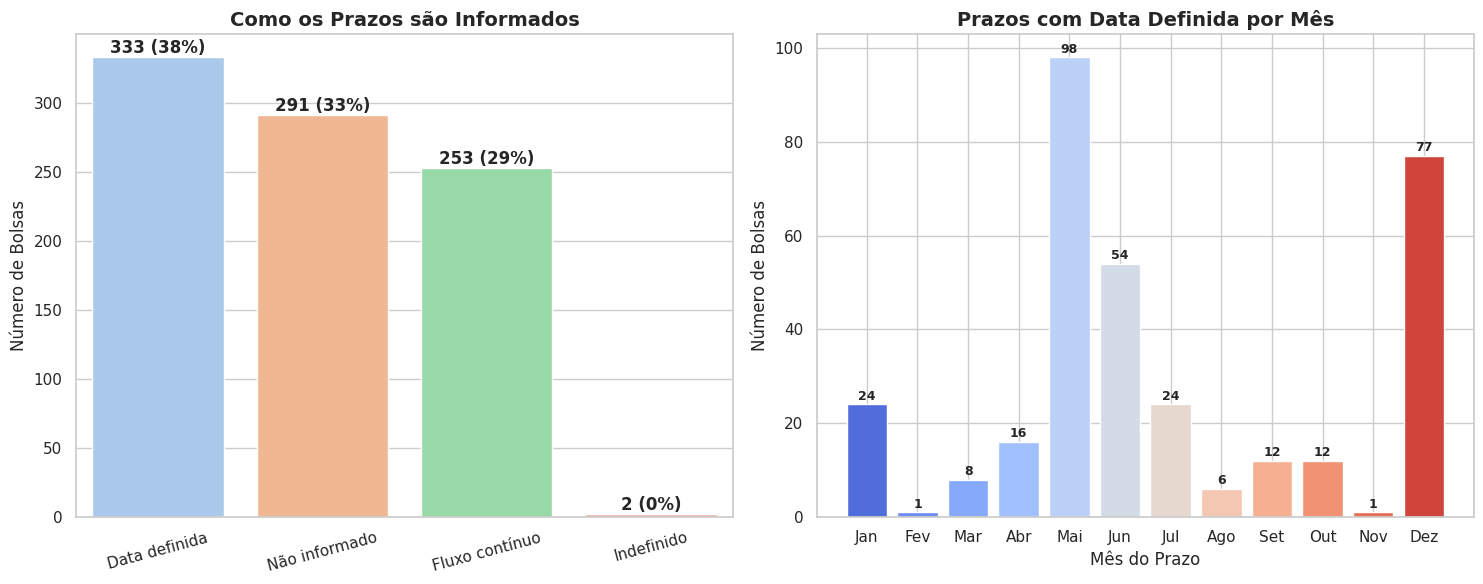

📅 Insights por Mês (entre bolsas com data definida):
✓ Jan: 24 bolsas (7.2% das datas definidas)
✓ Fev: 1 bolsas (0.3% das datas definidas)
✓ Mar: 8 bolsas (2.4% das datas definidas)
✓ Abr: 16 bolsas (4.8% das datas definidas)
✓ Mai: 98 bolsas (29.4% das datas definidas)
✓ Jun: 54 bolsas (16.2% das datas definidas)
✓ Jul: 24 bolsas (7.2% das datas definidas)
✓ Ago: 6 bolsas (1.8% das datas definidas)
✓ Set: 12 bolsas (3.6% das datas definidas)
✓ Out: 12 bolsas (3.6% das datas definidas)
✓ Nov: 1 bolsas (0.3% das datas definidas)
✓ Dez: 77 bolsas (23.1% das datas definidas)


In [19]:
# ## 5. Pergunta 4: Existe sazonalidade nos prazos de inscrição?
#
# **Hipótese:** entre as bolsas com data de prazo definida, as inscrições se concentram
# nos meses que antecedem os principais períodos de início do ano letivo no hemisfério
# norte (maio-julho, para ingresso em setembro, e dezembro-janeiro, para ingresso em
# janeiro).

# In[ ]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Status do prazo
ordem_status = df['prazo_status'].value_counts().index
sns.countplot(x='prazo_status', data=df, order=ordem_status, palette='pastel', ax=ax1)
ax1.set_title('Como os Prazos são Informados', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Número de Bolsas')
ax1.tick_params(axis='x', rotation=15)
for i, status in enumerate(ordem_status):
    total = (df['prazo_status'] == status).sum()
    ax1.text(i, total + 3, f'{total} ({total/len(df)*100:.0f}%)', ha='center', fontweight='bold')

# Gráfico 2: Distribuição mensal entre as bolsas com data definida
meses_ordem = ['January','February','March','April','May','June','July','August','September','October','November','December']
meses_pt = {'January':'Jan','February':'Fev','March':'Mar','April':'Abr','May':'Mai','June':'Jun',
            'July':'Jul','August':'Ago','September':'Set','October':'Out','November':'Nov','December':'Dez'}
contagem_mes = df['mes_prazo'].value_counts().reindex(meses_ordem, fill_value=0)
ax2.bar([meses_pt[m] for m in meses_ordem], contagem_mes.values, color=sns.color_palette('coolwarm', 12))
ax2.set_title('Prazos com Data Definida por Mês', fontsize=14, fontweight='bold')
ax2.set_xlabel('Mês do Prazo')
ax2.set_ylabel('Número de Bolsas')
for i, v in enumerate(contagem_mes.values):
    if v > 0:
        ax2.text(i, v + 1, f'{v}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("📅 Insights por Mês (entre bolsas com data definida):")
print("=" * 50)
for m in meses_ordem:
    v = contagem_mes[m]
    if v > 0:
        print(f"✓ {meses_pt[m]}: {v} bolsas ({v/contagem_mes.sum()*100:.1f}% das datas definidas)")


# **Insights**
# - Apenas 37,9% das bolsas têm uma data de prazo definida — 28,8% têm fluxo contínuo
#   ("Always Active") e 33,1% não informam prazo algum, o que já é, por si, um achado
#   relevante sobre a qualidade/consistência das fontes agregadas pelo portal.
# - Entre as datas definidas, maio (29,4%), junho (16,2%) e dezembro (23,1%) concentram
#   quase 70% dos prazos — um pico claro antes do intake de setembro e outro antes do
#   intake de janeiro.
# - Fevereiro e novembro têm praticamente nenhum prazo registrado, reforçando o padrão
#   de dois picos em vez de distribuição uniforme ao longo do ano.
#
# **Conclusões**
# - ✅ A hipótese se confirma: existe sazonalidade clara, com concentração de prazos
#   em maio-junho e dezembro, compatível com o calendário acadêmico do hemisfério
#   norte.
# - ⚠️ Qualquer recomendação baseada em "melhor mês para buscar bolsa" deve considerar
#   que quase 1 em cada 3 bolsas não tem prazo informado, e quase 1 em cada 3 aceita
#   inscrição o ano todo — a sazonalidade vale para uma fatia específica do dataset.

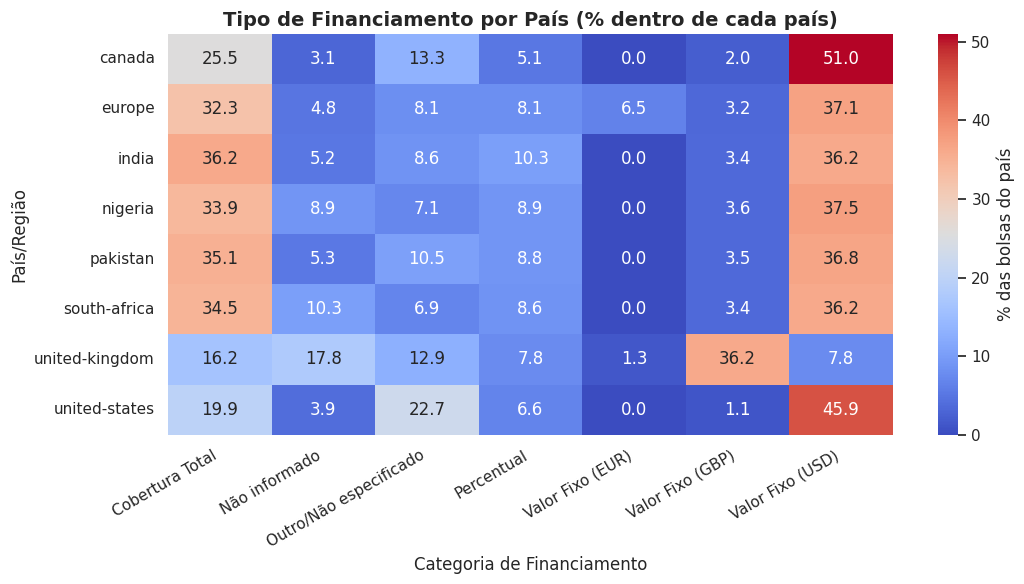

📐 Teste Qui-Quadrado — País x Categoria de Financiamento
Estatística qui-quadrado: 348.85 | Graus de liberdade: 42 | p-valor: 5.59e-50
✅ Associação estatisticamente muito significativa (p < 0.001).


In [21]:
# ## 6. Análise Multifatorial: Interação entre País e Financiamento
#
# Depois de investigar cada fator isoladamente, esta seção cruza país (`location`) e
# tipo de financiamento (`categoria_financiamento`) para identificar combinações
# atípicas e validar se a associação é estatisticamente robusta.

# In[ ]:


fig, ax = plt.subplots(figsize=(11, 6))

tabela_pais_financ = pd.crosstab(df['location'], df['categoria_financiamento'], normalize='index') * 100
sns.heatmap(tabela_pais_financ, annot=True, fmt='.1f', cmap='coolwarm', ax=ax,
            cbar_kws={'label': '% das bolsas do país'})
ax.set_title('Tipo de Financiamento por País (% dentro de cada país)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria de Financiamento')
ax.set_ylabel('País/Região')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Teste qui-quadrado: país x categoria de financiamento
tabela_bruta = pd.crosstab(df['location'], df['categoria_financiamento'])
chi2, p, dof, esperado = stats.chi2_contingency(tabela_bruta)

print("📐 Teste Qui-Quadrado — País x Categoria de Financiamento")
print("=" * 50)
print(f"Estatística qui-quadrado: {chi2:.2f} | Graus de liberdade: {dof} | p-valor: {p:.2e}")
print("✅ Associação estatisticamente muito significativa (p < 0.001)." if p < 0.05 else "❌ Sem associação significativa.")


In [22]:
print("🔍 Casos que mais se destacam na tabela país x financiamento:")
print("=" * 50)
print(f"✓ Reino Unido tem a MENOR taxa de Cobertura Total ({tabela_pais_financ.loc['united-kingdom','Cobertura Total']:.1f}%)")
print(f"  e a MENOR taxa de Valor Fixo (USD) ({tabela_pais_financ.loc['united-kingdom','Valor Fixo (USD)']:.1f}%) — coerente,")
print(f"  já que bolsas britânicas tendem a informar valor em £ (GBP), não em $.")
print(f"✓ Canadá tem a MAIOR taxa de Valor Fixo (USD) ({tabela_pais_financ.loc['canada','Valor Fixo (USD)']:.1f}%)")
print(f"  entre todos os países.")
print(f"✓ Índia, Paquistão, Nigéria e África do Sul têm perfis de financiamento muito")
print(f"  parecidos entre si (Cobertura Total em torno de 33-36%), diferentes do")
print(f"  padrão observado em Reino Unido, EUA e Canadá.")

print("\n🎓 Proporção de bolsas de PhD por país (ordem decrescente):")
print("=" * 50)
prop_phd_pais = (df.groupby('location')['nivel_phd'].mean() * 100).sort_values(ascending=False)
for pais, pct in prop_phd_pais.items():
    print(f"✓ {pais}: {pct:.1f}%")


# **Insights**
# - A associação entre país e tipo de financiamento é altamente significativa
#   (χ² = 348,8; p < 0,001) — a moeda/categoria do financiamento não é aleatória em
#   relação ao país, o que é esperado (bolsas britânicas informam valor em libras,
#   americanas em dólares), mas também revela diferenças reais de política de bolsa.
# - Índia, Paquistão, Nigéria e África do Sul formam um "cluster" de perfil de
#   financiamento semelhante — coincidem também com os países que mais oferecem bolsas
#   de PhD proporcionalmente (todos acima de 42%), sugerindo que bolsas voltadas a
#   esses países vêm mais de acordos de cooperação/pesquisa do que de bolsas de
#   graduação padrão.
# - Reino Unido, que domina em volume absoluto de bolsas, tem a menor proporção de PhD
#   (24,6%) e a menor cobertura total — a maior oferta do país é numericamente grande,
#   mas individualmente menos generosa.
#
# **Conclusões**
# - ✅ País é o fator mais determinante entre os investigados para prever o tipo de
#   financiamento (maior qui-quadrado e menor p-valor entre os testes realizados),
#   seguido de perto pelo nível de ensino (PhD).
# - ✅ Quem busca cobertura total de financiamento deve olhar preferencialmente para
#   bolsas de PhD e para os países do cluster África do Sul / Índia / Nigéria /
#   Paquistão, e não para o Reino Unido, apesar de este ser o país com mais
#   oportunidades listadas.
#

# ## 7. Conclusões Gerais e Recomendações
#
# ### Síntese dos achados
#
# | Fator investigado | Principal achado | Robustez estatística |
# |---|---|---|
# | País/Região | Reino Unido e EUA concentram 55,7% das bolsas listadas | Descritivo |
# | Nível de ensino x financiamento | PhD tem ~4x mais chance de cobertura total que os demais níveis | χ² muito significativo (p < 0,001) |
# | Tipo/valor de financiamento | Valor fixo em USD predomina (30%); valor não difere significativamente por país | Kruskal-Wallis no limiar (p ≈ 0,065) |
# | Sazonalidade de prazos | Picos em maio-junho e dezembro; 62% das bolsas não têm data fixa | Descritivo |
# | País x financiamento (multifatorial) | Forte associação; cluster de países emergentes com perfil semelhante | χ² muito significativo (p < 0,001) |
#
# ### Recomendações
#
# 1. **Para quem busca financiamento integral:** priorizar bolsas de doutorado (PhD) e,
#    dentro dessas, considerar oportunidades no cluster África do Sul / Índia / Nigéria
#    / Paquistão, onde a cobertura total é proporcionalmente mais comum.
# 2. **Para quem planeja o calendário de candidatura:** concentrar esforços de busca e
#    preparação de documentos entre março e junho (para prazos de maio-junho) e entre
#    outubro e dezembro (para prazos de dezembro) — mas sem deixar de investigar
#    programas de fluxo contínuo, que representam quase 29% do total.
# 3. **Para quem avalia o Reino Unido:** o volume de oportunidades é o maior do
#    dataset, mas a cobertura tende a ser parcial — vale complementar a busca com
#    bolsas de outros países se o objetivo for financiamento integral.
# 4. **Limitação do dataset:** 33,1% das bolsas não informam prazo e 9,7% não informam
#    valor de financiamento algum — qualquer decisão baseada nesses dados deve ser
#    cruzada com a página oficial de cada bolsa antes da candidatura.
#

🔍 Casos que mais se destacam na tabela país x financiamento:
✓ Reino Unido tem a MENOR taxa de Cobertura Total (16.2%)
  e a MENOR taxa de Valor Fixo (USD) (7.8%) — coerente,
  já que bolsas britânicas tendem a informar valor em £ (GBP), não em $.
✓ Canadá tem a MAIOR taxa de Valor Fixo (USD) (51.0%)
  entre todos os países.
✓ Índia, Paquistão, Nigéria e África do Sul têm perfis de financiamento muito
  parecidos entre si (Cobertura Total em torno de 33-36%), diferentes do
  padrão observado em Reino Unido, EUA e Canadá.

🎓 Proporção de bolsas de PhD por país (ordem decrescente):
✓ india: 44.8%
✓ pakistan: 43.9%
✓ south-africa: 43.1%
✓ nigeria: 42.9%
✓ europe: 40.3%
✓ canada: 37.8%
✓ united-states: 29.3%
✓ united-kingdom: 24.6%
